# Clifford Fitting 闭环教程（tianyan176）

演示 `client.run_auto(..., clifford_fitting=True)` 在真机后端 `tianyan176` 上对 ~8 比特、含非 Clifford 旋转与多层纠缠的线路进行误差缓解。

流程：
1. 构造一个 8 比特、含 `rx/ry/rz`（非 π/2 整数倍角度）与多层 `cx` 纠缠的线路；
2. 选定一组 Pauli 观测量（含 `ZZ`/`XX`/`YY` 关联）；
3. 先用 `Simulator` 后端（statevector）作为 noise-free 参考；
4. 在 `tianyan176` 上分别跑：
   * baseline（仅 readout mitigation + ZNE）；
   * baseline + clifford fitting。
5. 比较三组结果，确认 clifford fitting 把 raw 测量值向 ideal 参考方向拉近。

底层原理：在 `run_auto` 框架层一次性编译线路 → 用编译后的模板生成若干 Clifford-随机化校准线路 → 对每条同时在硬件和 Heisenberg-picture 模拟器（`sim.clifford` / `sim.clifford_t`）上求期望 → 每个观测量按 $E_\text{ideal} \approx a\cdot E_\text{noisy} + b$ 拟合并 clip 到 $[-1,1]$。

In [9]:
import logging
import math
import numpy as np

from fieldqkit import QuantumHardwareClient, QuantumCircuit

logging.basicConfig(level=logging.INFO, format="%(message)s", force=True)

def section(title: str):
    print("\n" + "=" * 18, title, "=" * 18)

## 1) 构造 8 比特非 Clifford 纠缠线路

结构：
* 第 0 层：每个比特 `H`；
* 第 1 层：线性 `cx` 链产生 GHZ-like 纠缠；
* 第 2 层：每个比特 `ry(θ_i)`，角度非 π/2 整数倍；
* 第 3 层：交错 `cx` 链；
* 第 4 层：每个比特 `rz(φ_i)`；
* 第 5 层：再来一层线性 `cx`；
* 第 6 层：每个比特 `rx(ψ_i)`。

总计 8 个 Hadamard + 21 个 CX + 24 个非 Clifford 旋转，足够触发足量噪声又仍能在 statevector 上参考。

In [ ]:
num_qubits = 4
rng = np.random.default_rng(2026)
thetas = rng.uniform(0.3, 1.2, size=num_qubits).tolist()

qc = QuantumCircuit(num_qubits)
for q in range(num_qubits):
    qc.h(q)
for q in range(num_qubits):
    qc.ry(float(thetas[q]), q)

print("total gates:", len(qc.gates))
print("non-clifford rotations:", sum(1 for g in qc.gates if g[0] in {"rx", "ry", "rz"}))

total gates: 8
non-clifford rotations: 4


## 2) 观测量

选取覆盖单点 Z、近邻 ZZ 关联和远端 XX/YY 关联的几个 Pauli 字符串。

In [40]:
observables = [
    "ZIII",  # Z on q0
    "IZII",  # Z on q1
    "ZZII",  # nearest-neighbor ZZ
    "IIZZ",  # middle ZZ
    "IIIZ",  # tail ZZ
    "XIIX",  # end-to-end XX
    "IYIY",  # YY across the chain
]
for obs in observables:
    print("  ", obs)

   ZIII
   IZII
   ZZII
   IIZZ
   IIIZ
   XIIX
   IYIY


## 3) Noise-free 参考（Simulator / statevector）

In [46]:
section("noise-free reference (Simulator)")
client = QuantumHardwareClient()

result_ref = client.run_auto(
    circuit=qc,
    name="cfit_ref_sv",
    num_qubits=num_qubits,
    shots=8192,
    observables=observables,
    prefer_chips="Simulator",
    print_true=False,
)
ideal_values = dict(result_ref.observable_values)
for obs in observables:
    print(f"  {obs}: {ideal_values[obs]:+.4f}")

If quantum circuit can be divided along the qubits, random initial mapping is restricted.



================== noise-free reference (Simulator) ==================
  ZIII: -0.4414
  IZII: -0.7620
  ZZII: +0.3303
  IIZZ: +0.3979
  IIIZ: -0.6025
  XIIX: +0.7224
  IYIY: -0.0032


## 4) Baseline：tianyan176 + readout mitigation + ZNE

不开 clifford fitting，先看真机原始噪声水平。

In [47]:
section("tianyan176 baseline")
result_base = client.run_auto(
    circuit=qc,
    name="cfit_tianyan_baseline",
    num_qubits=num_qubits,
    shots=4096,
    observables=observables,
    prefer_chips="tianyan176",
    readout_mitigation=True,
    readout_shots=2048,
    print_true=False,
)
base_values = dict(result_base.observable_values)
base_raw = dict(result_base.observable_values_raw)
for obs in observables:
    print(f"  {obs}: raw={base_raw[obs]:+.4f}  zne+rem={base_values[obs]:+.4f}  ideal={ideal_values[obs]:+.4f}")


================== tianyan176 baseline ==================


If quantum circuit can be divided along the qubits, random initial mapping is restricted.


  ZIII: raw=-0.3555  zne+rem=-0.4316  ideal=-0.4414
  IZII: raw=-0.6245  zne+rem=-0.6864  ideal=-0.7620
  ZZII: raw=+0.2476  zne+rem=+0.3304  ideal=+0.3303
  IIZZ: raw=+0.3779  zne+rem=+0.4019  ideal=+0.3979
  IIIZ: raw=-0.5430  zne+rem=-0.5588  ideal=-0.6025
  XIIX: raw=+0.6216  zne+rem=+0.8306  ideal=+0.7224
  IYIY: raw=+0.0142  zne+rem=+0.0165  ideal=-0.0032


## 5) 加上 clifford fitting

在 baseline 之上叠加 `clifford_fitting=True`。框架层会：
1. 一次性编译模板线路；
2. 在 `tianyan176` 上提交主任务（继承 ZNE + readout mitigation 参数）；
3. 用 `clifford_fitting_num_samples=8` 条 Clifford-随机化线路（其中 `num_non_clifford_gates=2` 条带 Haar 随机 U3）做校准；
4. 校准电路的 ideal 值由 `sim.clifford` 在 Heisenberg picture 下 $O(g\cdot n)$ 计算（非 Clifford 部分回退到 `sim.clifford_t` 的分支扩展）；
5. 每个观测量拟合 $E_\text{ideal}\approx a\,E_\text{noisy} + b$，应用到主任务结果上并 clip 到 $[-1,1]$。

In [48]:
section("tianyan176 + clifford fitting")
result_cfit = client.run_auto(
    circuit=qc,
    name="cfit_tianyan_with_fitting",
    num_qubits=num_qubits,
    shots=4096,
    observables=observables,
    prefer_chips="tianyan176",
    readout_mitigation=True,
    readout_shots=2048,
    clifford_fitting=True,
    clifford_fitting_num_samples=8,
    clifford_fitting_num_non_clifford_gates=2,
    clifford_fitting_seed=2026,
    print_true=False,
)
cfit_values = dict(result_cfit.observable_values)
cfit_raw = dict(result_cfit.observable_values_raw)
for obs in observables:
    print(
        f"  {obs}: raw={cfit_raw[obs]:+.4f}  zne+rem+cfit={cfit_values[obs]:+.4f}  ideal={ideal_values[obs]:+.4f}"
    )


================== tianyan176 + clifford fitting ==================


If quantum circuit can be divided along the qubits, random initial mapping is restricted.


  ZIII: raw=-0.3574  zne+rem+cfit=-0.3966  ideal=-0.4414
  IZII: raw=-0.6436  zne+rem+cfit=-0.7764  ideal=-0.7620
  ZZII: raw=+0.2285  zne+rem+cfit=+0.3188  ideal=+0.3303
  IIZZ: raw=+0.3950  zne+rem+cfit=+0.4165  ideal=+0.3979
  IIIZ: raw=-0.5630  zne+rem+cfit=-0.6214  ideal=-0.6025
  XIIX: raw=+0.6294  zne+rem+cfit=+1.0000  ideal=+0.7224
  IYIY: raw=+0.0044  zne+rem+cfit=+0.0226  ideal=-0.0032


## 6) 汇总比较

用 $\ell_1$ 误差衡量三组结果对 ideal 的偏离。理想情况下：
$$\text{err}_\text{cfit} \le \text{err}_\text{zne+rem} \le \text{err}_\text{raw}.$$

In [49]:
def l1_error(estimated: dict, reference: dict) -> float:
    return float(sum(abs(estimated[k] - reference[k]) for k in reference) / len(reference))

err_raw = l1_error(base_raw, ideal_values)
err_base = l1_error(base_values, ideal_values)
err_cfit = l1_error(cfit_values, ideal_values)

print(f"mean |E - E_ideal|:")
print(f"  raw (1x, no mitigation):  {err_raw:.4f}")
print(f"  zne + readout mitigation: {err_base:.4f}")
print(f"  + clifford fitting:       {err_cfit:.4f}")

mean |E - E_ideal|:
  raw (1x, no mitigation):  0.0720
  zne + readout mitigation: 0.0373
  + clifford fitting:       0.0588


## 7) 可视化

条形对比 raw / zne+rem / cfit / ideal。

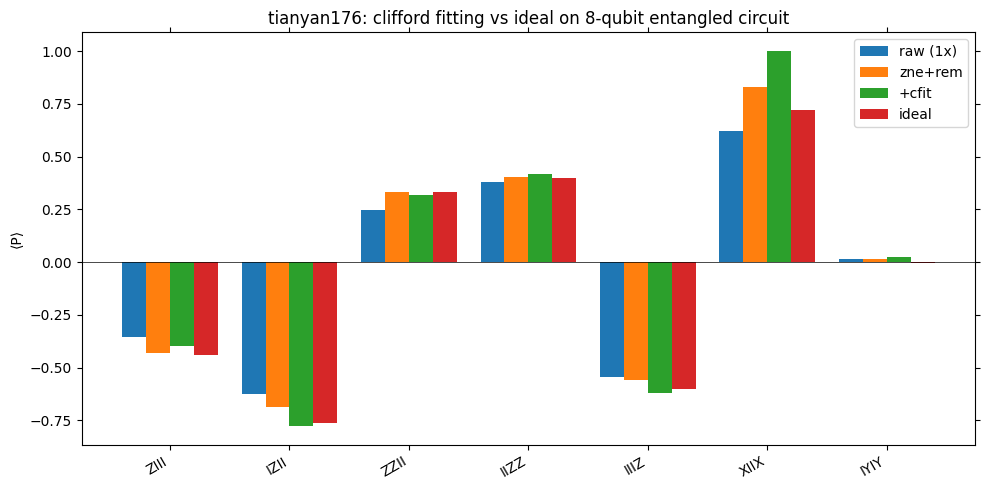

In [51]:
import matplotlib.pyplot as plt

labels = list(observables)
xs = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(xs - 1.5 * width, [base_raw[o] for o in labels],   width, label="raw (1x)")
ax.bar(xs - 0.5 * width, [base_values[o] for o in labels], width, label="zne+rem")
ax.bar(xs + 0.5 * width, [cfit_values[o] for o in labels], width, label="+cfit")
ax.bar(xs + 1.5 * width, [ideal_values[o] for o in labels], width, label="ideal")
ax.axhline(0, color="black", lw=0.5)
ax.set_xticks(xs)
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylabel("⟨P⟩")
ax.set_title("tianyan176: clifford fitting vs ideal on 8-qubit entangled circuit")
ax.legend()
ax.tick_params(top=True, right=True)
plt.tight_layout()
plt.show()